# Unconstrained Oblique Baselines: SPORF + Oblique FIGS

This notebook runs **4 oblique tree methods** on tabular datasets with 5-fold cross-validation,
measuring accuracy/R² and **direction diversity metrics** (eRank, stable rank, participation ratio).

**Methods compared:**
1. **ManualSPORF Matched** — sklearn RandomForest with random sparse projections (complexity-matched to FIGS)
2. **ManualSPORF Full** — SPORF with more estimators and deeper trees
3. **ObliqueFIGS** — FIGS with unconstrained oblique splits via Ridge/PCA/random projections
4. **FIGS Axis-Aligned** — Standard imodels FIGS baseline

The key insight: SPORF achieves higher direction diversity (eRank) through random projections,
while FIGS methods use fewer but more targeted split directions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels — NOT on Colab, always install
_pip('imodels==2.0.4')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from imodels import FIGSClassifier, FIGSRegressor
from scipy.stats import mode
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/experiment_iter2_unconstrained_o/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  diabetes_pima: 100 examples


## Configuration

All tunable parameters for the experiment. Adjust these to trade off between runtime and result quality.

In [5]:
# ── SPORF Matched (complexity-matched to FIGS) ──
SPORF_MATCHED_N_ESTIMATORS = 6    # original: 6
SPORF_MATCHED_MAX_DEPTH = 2       # original: 2

# ── SPORF Full ──
SPORF_FULL_N_ESTIMATORS = 50      # original: 50
SPORF_FULL_MAX_DEPTH = 10         # original: 10

# ── Shared SPORF parameter ──
FEATURE_COMBINATIONS = 1.5        # original: 1.5

# ── Oblique FIGS ──
OBLIQUE_FIGS_MAX_RULES = 12       # original: 12
OBLIQUE_FIGS_MAX_TREES = 5        # original: 5
OBLIQUE_FIGS_MAX_DEPTH = 4        # original: 4

# ── FIGS Axis-Aligned ──
FIGS_AA_MAX_RULES = 12            # original: 12
FIGS_AA_MAX_TREES = 5             # original: 5
FIGS_AA_MAX_DEPTH = 4             # original: 4

# ── Number of CV folds to use (None = all available) ──
N_FOLDS_TO_USE = None             # original: None (all 5 folds)

## Direction Diversity Metrics

Compute eRank, stable rank, participation ratio, and near-duplicate counts from a matrix of split direction vectors. These metrics quantify how "spread out" the oblique split directions are in feature space.

In [6]:
def compute_direction_diversity(W: np.ndarray) -> dict:
    """Compute direction diversity metrics from a matrix of split directions.

    Args:
        W: np.array of shape (N_splits, d) — each row is a split direction vector.

    Returns:
        Dictionary of diversity metrics.
    """
    if W.shape[0] < 2:
        return {
            "erank": 1.0, "stable_rank": 1.0, "participation_ratio": 1.0,
            "n_near_duplicates": 0, "avg_pairwise_cosine_sim": 0.0,
            "n_total_splits": int(W.shape[0]),
            "svd_top5_singular_values": [1.0],
        }

    # Normalize each row to unit norm
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-10)
    W_normed = W / norms

    # SVD
    _U, sigma, _Vt = np.linalg.svd(W_normed, full_matrices=False)
    sigma = sigma[sigma > 1e-10]

    if len(sigma) == 0:
        return {
            "erank": 1.0, "stable_rank": 1.0, "participation_ratio": 1.0,
            "n_near_duplicates": 0, "avg_pairwise_cosine_sim": 0.0,
            "n_total_splits": int(W.shape[0]),
            "svd_top5_singular_values": [],
        }

    sigma_sq = sigma ** 2

    # 1. eRank = exp(Shannon entropy of normalized singular values)
    p = sigma_sq / sigma_sq.sum()
    p = p[p > 1e-15]
    erank = float(np.exp(-np.sum(p * np.log(p))))

    # 2. Stable rank = ||W||_F^2 / ||W||_2^2
    stable_rank = float(sigma_sq.sum() / sigma_sq[0])

    # 3. Participation ratio = (sum sigma_i^2)^2 / sum(sigma_i^4)
    participation_ratio = float((sigma_sq.sum())**2 / (sigma_sq**2).sum())

    # 4. Near-duplicate directions and average cosine similarity
    n = W_normed.shape[0]
    if n <= 500:
        cos_sim = np.abs(W_normed @ W_normed.T)
        np.fill_diagonal(cos_sim, 0)
        n_near_duplicates = int(np.sum(cos_sim > 0.95)) // 2
        avg_cos_sim = float(cos_sim.sum() / (n * (n - 1))) if n > 1 else 0.0
    else:
        n_pairs = 500
        rng = np.random.RandomState(42)
        idx1 = rng.choice(n, n_pairs)
        idx2 = rng.choice(n, n_pairs)
        cos_sims = np.abs(np.sum(W_normed[idx1] * W_normed[idx2], axis=1))
        n_near_duplicates = int(np.sum(cos_sims > 0.95))
        avg_cos_sim = float(np.mean(cos_sims))

    return {
        "erank": erank,
        "stable_rank": stable_rank,
        "participation_ratio": participation_ratio,
        "n_near_duplicates": n_near_duplicates,
        "avg_pairwise_cosine_sim": avg_cos_sim,
        "n_total_splits": int(W.shape[0]),
        "svd_top5_singular_values": sigma[:5].tolist(),
    }

## Manual SPORF (Sparse Projection Oblique Random Forest)

SPORF implementation using sklearn decision trees with random sparse projection matrices. Each tree operates on a randomly projected version of the feature space, creating oblique decision boundaries.

In [7]:
class ManualSPORF:
    """SPORF implementation using sklearn trees + random sparse projections.

    For each tree:
      1. Generate random sparse projection matrix P of shape (n_projected, n_features)
      2. Transform X_proj = X @ P.T
      3. Fit sklearn DecisionTree on X_proj
      4. Store P to reconstruct oblique directions
    """

    def __init__(
        self,
        n_estimators: int = 100,
        max_depth: int | None = None,
        feature_combinations: float = 1.5,
        random_state: int = 42,
        task_type: str = "classification",
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.feature_combinations = feature_combinations
        self.random_state = random_state
        self.task_type = task_type
        self.estimators_ = []
        self.projection_matrices_ = []

    def _generate_projection_matrix(
        self, n_features: int, rng: np.random.RandomState
    ) -> np.ndarray:
        """Generate a random sparse projection matrix."""
        n_proj = n_features
        P = np.zeros((n_proj, n_features))
        prob = self.feature_combinations / n_features
        prob = min(prob, 1.0)
        for i in range(n_proj):
            mask = rng.random(n_features) < prob
            if not mask.any():
                mask[rng.randint(n_features)] = True
            P[i, mask] = rng.choice([-1.0, 1.0], size=mask.sum())
        return P

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ManualSPORF":
        """Fit the SPORF ensemble."""
        n_features = X.shape[1]
        rng = np.random.RandomState(self.random_state)

        self.estimators_ = []
        self.projection_matrices_ = []

        for i in range(self.n_estimators):
            seed = rng.randint(0, 2**31)
            P = self._generate_projection_matrix(n_features, np.random.RandomState(seed))
            X_proj = X @ P.T

            if self.task_type == "classification":
                tree = DecisionTreeClassifier(
                    max_depth=self.max_depth,
                    random_state=seed,
                    max_features="sqrt",
                )
            else:
                tree = DecisionTreeRegressor(
                    max_depth=self.max_depth,
                    random_state=seed,
                    max_features="sqrt",
                )

            # Bootstrap sample
            n = X.shape[0]
            boot_idx = rng.choice(n, size=n, replace=True)
            tree.fit(X_proj[boot_idx], y[boot_idx])

            self.estimators_.append(tree)
            self.projection_matrices_.append(P)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict using majority vote (classification) or mean (regression)."""
        if self.task_type == "classification":
            all_preds = np.array([
                est.predict(X @ P.T)
                for est, P in zip(self.estimators_, self.projection_matrices_)
            ])
            result = mode(all_preds, axis=0, keepdims=False)
            return result.mode.flatten()
        else:
            all_preds = np.array([
                est.predict(X @ P.T)
                for est, P in zip(self.estimators_, self.projection_matrices_)
            ])
            return np.mean(all_preds, axis=0)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict class probabilities (average across trees)."""
        all_proba = []
        for est, P in zip(self.estimators_, self.projection_matrices_):
            proba = est.predict_proba(X @ P.T)
            all_proba.append(proba)

        n_classes = max(p.shape[1] for p in all_proba)
        aligned = []
        for p in all_proba:
            if p.shape[1] < n_classes:
                padded = np.zeros((p.shape[0], n_classes))
                padded[:, :p.shape[1]] = p
                aligned.append(padded)
            else:
                aligned.append(p)

        return np.mean(aligned, axis=0)

    def extract_split_directions(self, n_features: int) -> np.ndarray:
        """Extract oblique split directions in original feature space."""
        directions = []
        for est, P in zip(self.estimators_, self.projection_matrices_):
            tree = est.tree_
            TREE_LEAF = -1
            for node_idx in range(tree.node_count):
                if tree.children_left[node_idx] != TREE_LEAF:
                    feat = tree.feature[node_idx]
                    if 0 <= feat < P.shape[0]:
                        direction = P[feat].copy()
                        if np.linalg.norm(direction) > 1e-10:
                            directions.append(direction)

        if directions:
            return np.array(directions)
        return np.zeros((0, n_features))

## Unconstrained Oblique FIGS

FIGS with oblique splits found via Ridge regression, PCA, and random projections. Uses the greedy-additive-tree algorithm from FIGS but replaces axis-aligned splits with oblique splits.

In [8]:
class ObliqueFIGSNode:
    """Node in an Oblique FIGS tree."""
    __slots__ = [
        'weights', 'threshold', 'value', 'left', 'right',
        'left_temp', 'right_temp', 'idxs', 'is_root', 'tree_num',
        'depth', 'impurity', 'impurity_reduction',
    ]

    def __init__(self):
        self.weights = None
        self.threshold = None
        self.value = None
        self.left = None
        self.right = None
        self.left_temp = None
        self.right_temp = None
        self.idxs = None
        self.is_root = False
        self.tree_num = -1
        self.depth = 0
        self.impurity = 0.0
        self.impurity_reduction = None


class ObliqueFIGS:
    """FIGS with unconstrained oblique splits."""

    def __init__(
        self,
        max_rules: int = 12,
        max_trees: int | None = None,
        max_depth: int | None = None,
        min_impurity_decrease: float = 0.0,
        n_candidate_directions: int = 5,
        task_type: str = "classification",
    ):
        self.max_rules = max_rules
        self.max_trees = max_trees
        self.max_depth = max_depth
        self.min_impurity_decrease = min_impurity_decrease
        self.n_candidate_directions = n_candidate_directions
        self.task_type = task_type
        self.trees_ = []
        self.complexity_ = 0
        self.classes_ = None

    def _compute_impurity_reduction(
        self, y: np.ndarray, left_mask: np.ndarray, right_mask: np.ndarray,
    ) -> float:
        """Compute MSE-based impurity reduction."""
        n = len(y)
        n_left = int(left_mask.sum())
        n_right = int(right_mask.sum())
        if n_left < 2 or n_right < 2:
            return -np.inf

        if y.ndim == 1:
            parent_var = np.var(y) * n
            left_var = np.var(y[left_mask]) * n_left
            right_var = np.var(y[right_mask]) * n_right
        else:
            parent_var = np.sum(np.var(y, axis=0)) * n
            left_var = np.sum(np.var(y[left_mask], axis=0)) * n_left
            right_var = np.sum(np.var(y[right_mask], axis=0)) * n_right

        return float((parent_var - left_var - right_var) / n)

    def _find_best_oblique_split(
        self, X: np.ndarray, y: np.ndarray, idxs: np.ndarray
    ) -> ObliqueFIGSNode | None:
        """Find the best oblique split for data at this node."""
        X_node = X[idxs]
        y_node = y[idxs]
        n_node, d = X_node.shape

        if n_node < 5:
            return None

        candidate_directions = []

        # Direction source 1: Ridge regression
        try:
            if n_node <= 2000:
                XtX = X_node.T @ X_node
                XtX[np.diag_indices_from(XtX)] += 1.0
                if y_node.ndim == 1:
                    Xty = X_node.T @ y_node
                else:
                    if y_node.shape[1] <= 2:
                        y_1d = y_node[:, 0] - y_node[:, -1]
                    else:
                        y_mean = y_node - y_node.mean(axis=0)
                        _U, _s, Vt = np.linalg.svd(y_mean, full_matrices=False)
                        y_1d = y_mean @ Vt[0]
                    Xty = X_node.T @ y_1d
                w = np.linalg.solve(XtX, Xty).flatten()
                if w.shape[0] == d:
                    w_norm = np.linalg.norm(w)
                    if w_norm > 1e-10:
                        candidate_directions.append(w / w_norm)
        except Exception:
            pass

        # Direction source 2: PCA top-2 directions
        try:
            X_centered = X_node - X_node.mean(axis=0)
            if n_node > d:
                cov = (X_centered.T @ X_centered) / n_node
                eigvals, eigvecs = np.linalg.eigh(cov)
                for j in range(min(2, d)):
                    comp = eigvecs[:, -(j + 1)]
                    candidate_directions.append(comp)
            else:
                _U, _s, Vt = np.linalg.svd(X_centered, full_matrices=False)
                for j in range(min(2, Vt.shape[0])):
                    candidate_directions.append(Vt[j])
        except Exception:
            pass

        # Direction source 3: Random sparse projections
        rng = np.random.RandomState(abs(hash(idxs.tobytes())) % (2**31))
        for _ in range(2):
            w_rand = np.zeros(d)
            k = max(2, int(1.5 * np.sqrt(d)))
            feats = rng.choice(d, size=min(k, d), replace=False)
            w_rand[feats] = rng.standard_normal(len(feats))
            w_rand_norm = np.linalg.norm(w_rand)
            if w_rand_norm > 1e-10:
                candidate_directions.append(w_rand / w_rand_norm)

        # Direction source 4: axis-aligned directions (top 3 by variance)
        if y_node.ndim == 1:
            var_per_feat = np.array([
                np.var(y_node[X_node[:, j] <= np.median(X_node[:, j])]) * (n_node // 2)
                + np.var(y_node[X_node[:, j] > np.median(X_node[:, j])]) * (n_node - n_node // 2)
                for j in range(min(d, 10))
            ])
            top_feats = np.argsort(var_per_feat)[:3]
        else:
            top_feats = rng.choice(d, size=min(3, d), replace=False)
        for j in top_feats:
            e_j = np.zeros(d)
            e_j[j] = 1.0
            candidate_directions.append(e_j)

        # For each candidate direction, find optimal threshold
        best_reduction = -np.inf
        best_weights = None
        best_threshold = None

        for w in candidate_directions:
            w = np.asarray(w).flatten()
            if w.ndim != 1 or w.shape[0] != d:
                continue
            z = X_node @ w

            sort_idx = np.argsort(z)
            z_sorted = z[sort_idx]
            y_sorted = y_node[sort_idx]

            n_total = len(z_sorted)
            if n_total < 4:
                continue

            if n_total > 60:
                pct_positions = np.unique(np.percentile(
                    np.arange(n_total), np.linspace(5, 95, 25)
                ).astype(int))
                pct_positions = pct_positions[(pct_positions >= 2) & (pct_positions < n_total - 2)]
            else:
                pct_positions = np.arange(2, n_total - 2)

            if len(pct_positions) == 0:
                continue

            if y_sorted.ndim == 1:
                cumsum = np.cumsum(y_sorted)
                cumsum_sq = np.cumsum(y_sorted ** 2)
                total_sum = cumsum[-1]
                total_sum_sq = cumsum_sq[-1]

                for pos in pct_positions:
                    n_left = pos + 1
                    n_right = n_total - n_left
                    if n_left < 2 or n_right < 2:
                        continue

                    left_sum = cumsum[pos]
                    left_sq = cumsum_sq[pos]
                    right_sum = total_sum - left_sum
                    right_sq = total_sum_sq - left_sq

                    left_var = left_sq / n_left - (left_sum / n_left) ** 2
                    right_var = right_sq / n_right - (right_sum / n_right) ** 2
                    parent_var = total_sum_sq / n_total - (total_sum / n_total) ** 2

                    reduction = parent_var - (n_left * left_var + n_right * right_var) / n_total
                    if reduction > best_reduction:
                        best_reduction = float(reduction)
                        best_weights = w.copy()
                        best_threshold = float((z_sorted[pos] + z_sorted[pos + 1]) / 2)
            else:
                n_out = y_sorted.shape[1]
                cumsum = np.cumsum(y_sorted, axis=0)
                cumsum_sq = np.cumsum(y_sorted ** 2, axis=0)
                total_sum = cumsum[-1]
                total_sum_sq = cumsum_sq[-1]

                for pos in pct_positions:
                    n_left = pos + 1
                    n_right = n_total - n_left
                    if n_left < 2 or n_right < 2:
                        continue

                    left_sum = cumsum[pos]
                    left_sq = cumsum_sq[pos]
                    right_sum = total_sum - left_sum
                    right_sq = total_sum_sq - left_sq

                    left_var = np.sum(left_sq / n_left - (left_sum / n_left) ** 2)
                    right_var = np.sum(right_sq / n_right - (right_sum / n_right) ** 2)
                    parent_var = np.sum(total_sum_sq / n_total - (total_sum / n_total) ** 2)

                    reduction = parent_var - (n_left * left_var + n_right * right_var) / n_total
                    if reduction > best_reduction:
                        best_reduction = float(reduction)
                        best_weights = w.copy()
                        best_threshold = float((z_sorted[pos] + z_sorted[pos + 1]) / 2)

        if best_weights is None or best_reduction <= 0:
            return None

        node = ObliqueFIGSNode()
        node.weights = best_weights
        node.threshold = best_threshold
        node.impurity_reduction = best_reduction
        node.impurity = float(np.var(y_node) if y_node.ndim == 1 else np.sum(np.var(y_node, axis=0)))
        node.idxs = idxs.copy()
        node.value = np.mean(y_node, axis=0)

        full_z = X @ best_weights
        left_idxs = idxs & (full_z <= best_threshold)
        right_idxs = idxs & (full_z > best_threshold)

        node.left_temp = ObliqueFIGSNode()
        node.left_temp.idxs = left_idxs
        node.left_temp.value = np.mean(y[left_idxs], axis=0) if left_idxs.any() else (
            np.zeros_like(node.value)
        )

        node.right_temp = ObliqueFIGSNode()
        node.right_temp.idxs = right_idxs
        node.right_temp.value = np.mean(y[right_idxs], axis=0) if right_idxs.any() else (
            np.zeros_like(node.value)
        )

        return node

    def fit(self, X: np.ndarray, y_original: np.ndarray) -> "ObliqueFIGS":
        """FIGS greedy loop with oblique splits."""
        n_samples = X.shape[0]

        if self.task_type == "classification":
            classes = np.unique(y_original)
            n_classes = len(classes)
            y = np.zeros((n_samples, n_classes))
            for i, c in enumerate(classes):
                y[y_original == c, i] = 1.0
            self.classes_ = classes
        else:
            y = y_original.copy().astype(float)
            if y.ndim == 1:
                y = y.reshape(-1, 1)

        self.trees_ = []
        self.complexity_ = 0

        y_pred_total = np.zeros_like(y)
        y_predictions_per_tree = {}
        idxs_all = np.ones(n_samples, dtype=bool)

        def find_split_info(X_data, y_target, idxs):
            result = self._find_best_oblique_split(X_data, y_target, idxs)
            if result is None:
                return None
            return {
                "weights": result.weights,
                "threshold": result.threshold,
                "impurity_reduction": result.impurity_reduction,
                "left_idxs": result.left_temp.idxs if result.left_temp else idxs,
                "right_idxs": result.right_temp.idxs if result.right_temp else idxs,
                "left_value": result.left_temp.value if result.left_temp else result.value,
                "right_value": result.right_temp.value if result.right_temp else result.value,
                "idxs": idxs,
            }

        y_residuals = y - y_pred_total
        init_info = find_split_info(X, y_residuals, idxs_all)
        if init_info is None:
            return self

        potential_splits = [(None, init_info, True, -1, 0)]

        while potential_splits and self.complexity_ < self.max_rules:
            potential_splits.sort(
                key=lambda t: t[1]["impurity_reduction"] if t[1] and t[1]["impurity_reduction"] else -np.inf
            )
            leaf_node, split_info, is_new_root, tree_num, depth = potential_splits.pop()

            if split_info is None or split_info["impurity_reduction"] <= self.min_impurity_decrease:
                break

            if self.max_depth is not None and depth >= self.max_depth:
                continue

            if is_new_root:
                if self.max_trees is not None and len(self.trees_) >= self.max_trees:
                    continue

                root = ObliqueFIGSNode()
                root.is_root = True
                root.tree_num = len(self.trees_)
                root.depth = 0
                root.idxs = idxs_all.copy()
                root.value = np.mean(y_residuals, axis=0) if y_residuals is not None else np.zeros(y.shape[1:])
                tree_num = root.tree_num
                depth = 0
                self.trees_.append(root)
                y_predictions_per_tree[tree_num] = np.zeros_like(y)
                leaf_node = root

                y_residuals = y - y_pred_total
                next_root_info = find_split_info(X, y_residuals, idxs_all)
                if next_root_info is not None:
                    potential_splits.append((None, next_root_info, True, -1, 0))

            leaf_node.weights = split_info["weights"]
            leaf_node.threshold = split_info["threshold"]
            leaf_node.impurity_reduction = split_info["impurity_reduction"]

            left_child = ObliqueFIGSNode()
            left_child.idxs = split_info["left_idxs"]
            left_child.value = split_info["left_value"]
            left_child.tree_num = tree_num
            left_child.depth = depth + 1

            right_child = ObliqueFIGSNode()
            right_child.idxs = split_info["right_idxs"]
            right_child.value = split_info["right_value"]
            right_child.tree_num = tree_num
            right_child.depth = depth + 1

            leaf_node.left = left_child
            leaf_node.right = right_child
            self.complexity_ += 1

            y_predictions_per_tree[tree_num] = self._predict_tree_train(
                self.trees_[tree_num], X, y.shape
            )
            y_pred_total = sum(y_predictions_per_tree.values())
            y_residuals = y - y_pred_total

            for child in [left_child, right_child]:
                if child.idxs.sum() >= 5:
                    if tree_num in y_predictions_per_tree:
                        y_target = y - (y_pred_total - y_predictions_per_tree[tree_num])
                    else:
                        y_target = y_residuals
                    child_info = find_split_info(X, y_target, child.idxs)
                    if child_info is not None and child_info["impurity_reduction"] > 0:
                        potential_splits.append(
                            (child, child_info, False, tree_num, child.depth)
                        )

            new_potential = []
            has_root_candidate = False
            for (pn, pi, pnr, ptn, pd) in potential_splits:
                if pnr and not has_root_candidate:
                    updated = find_split_info(X, y_residuals, idxs_all)
                    if updated is not None and updated["impurity_reduction"] > 0:
                        new_potential.append((None, updated, True, -1, 0))
                        has_root_candidate = True
                elif not pnr:
                    new_potential.append((pn, pi, pnr, ptn, pd))
            potential_splits = new_potential

        return self

    def _predict_tree_train(
        self, root: ObliqueFIGSNode, X: np.ndarray, shape: tuple
    ) -> np.ndarray:
        preds = np.full(shape, 0.0)
        self._fill_predictions(root, preds)
        return preds

    def _fill_predictions(self, node: ObliqueFIGSNode, preds: np.ndarray):
        if node is None:
            return
        if node.left is None and node.right is None:
            if node.idxs is not None:
                preds[node.idxs] = node.value
            return
        if node.left is not None:
            self._fill_predictions(node.left, preds)
        if node.right is not None:
            self._fill_predictions(node.right, preds)

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self.trees_:
            if self.task_type == "classification":
                return np.zeros(X.shape[0], dtype=int)
            return np.zeros(X.shape[0])

        sample_val = self.trees_[0].value
        if np.isscalar(sample_val):
            val_shape = ()
        else:
            val_shape = sample_val.shape

        y_pred = np.zeros((X.shape[0],) + val_shape)
        for tree_root in self.trees_:
            y_pred += self._predict_tree_test(tree_root, X, val_shape)

        if self.task_type == "classification" and self.classes_ is not None:
            return self.classes_[np.argmax(y_pred, axis=1)]
        else:
            return y_pred.flatten()

    def _predict_tree_test(
        self, node: ObliqueFIGSNode, X: np.ndarray, val_shape: tuple
    ) -> np.ndarray:
        preds = np.zeros((X.shape[0],) + val_shape)
        self._route_and_predict(node, X, np.arange(X.shape[0]), preds)
        return preds

    def _route_and_predict(
        self, node: ObliqueFIGSNode, X: np.ndarray,
        sample_indices: np.ndarray, preds: np.ndarray,
    ):
        if node is None:
            return
        if node.left is None and node.right is None:
            preds[sample_indices] = node.value
            return
        if node.weights is None:
            preds[sample_indices] = node.value
            return

        z = X[sample_indices] @ node.weights
        left_mask = z <= node.threshold
        left_indices = sample_indices[left_mask]
        right_indices = sample_indices[~left_mask]
        if len(left_indices) > 0 and node.left is not None:
            self._route_and_predict(node.left, X, left_indices, preds)
        if len(right_indices) > 0 and node.right is not None:
            self._route_and_predict(node.right, X, right_indices, preds)

    def extract_split_directions(self) -> np.ndarray:
        directions = []
        for tree_root in self.trees_:
            self._collect_directions(tree_root, directions)
        if directions:
            return np.array(directions)
        return np.zeros((0, 1))

    def _collect_directions(self, node: ObliqueFIGSNode, directions: list):
        if node is None or (node.left is None and node.right is None):
            return
        if hasattr(node, 'weights') and node.weights is not None:
            directions.append(node.weights.copy())
        self._collect_directions(node.left, directions)
        self._collect_directions(node.right, directions)

## FIGS Axis-Aligned Direction Extraction

Extract axis-aligned split directions from standard imodels FIGS models for comparison with oblique methods.

In [9]:
def extract_figs_directions(model, n_features: int) -> np.ndarray:
    """Extract axis-aligned directions from an imodels FIGS model."""
    directions = []

    def traverse(node):
        if node is None:
            return
        if node.left is not None:  # internal node
            direction = np.zeros(n_features)
            if hasattr(node, 'feature') and node.feature is not None:
                feat_idx = int(node.feature)
                if 0 <= feat_idx < n_features:
                    direction[feat_idx] = 1.0
                    directions.append(direction)
            traverse(node.left)
        if node.right is not None:
            traverse(node.right)

    if hasattr(model, 'trees_'):
        for tree_root in model.trees_:
            traverse(tree_root)

    if directions:
        return np.array(directions)
    return np.zeros((0, n_features))

## Data Parsing & Evaluation Functions

Parse the loaded JSON data into numpy arrays and run cross-validated evaluation for each method.

In [10]:
def load_datasets(raw_data: dict) -> dict:
    """Parse datasets from the loaded JSON data.

    Returns:
        Dict mapping dataset name to {X, y, task_type, fold_labels, n_features, n_classes}.
    """
    datasets = {}

    for ds in raw_data["datasets"]:
        name = ds["dataset"]
        if name.endswith("_mini"):
            continue

        examples = ds["examples"]
        X = np.array([json.loads(ex["input"]) for ex in examples])
        y_str = [ex["output"] for ex in examples]
        task_type = examples[0]["metadata_task_type"]
        fold_labels = np.array([ex["metadata_fold"] for ex in examples])
        n_features = X.shape[1]

        if task_type == "classification":
            y = np.array([int(float(s)) for s in y_str])
            n_classes = int(examples[0].get("metadata_n_classes", len(np.unique(y))))
        else:
            y = np.array([float(s) for s in y_str])
            n_classes = 0

        datasets[name] = {
            "X": X, "y": y, "task_type": task_type,
            "fold_labels": fold_labels, "n_features": n_features,
            "n_classes": n_classes,
        }
        print(
            f"  {name}: X={X.shape}, task={task_type}, "
            f"folds={sorted(np.unique(fold_labels).tolist())}"
        )

    print(f"Loaded {len(datasets)} datasets")
    return datasets


def evaluate_sporf(
    X, y, fold_labels, task_type, n_features, n_classes,
    n_estimators=100, max_depth=None, feature_combinations=1.5,
):
    """Evaluate ManualSPORF with CV."""
    folds = sorted(np.unique(fold_labels).tolist())
    if N_FOLDS_TO_USE is not None:
        folds = folds[:N_FOLDS_TO_USE]
    fold_results = []

    for fold in folds:
        train_mask = fold_labels != fold
        test_mask = fold_labels == fold

        if test_mask.sum() < 2 or train_mask.sum() < 5:
            continue

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)

        model = ManualSPORF(
            n_estimators=n_estimators, max_depth=max_depth,
            feature_combinations=feature_combinations,
            random_state=42 + fold, task_type=task_type,
        )
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

        result = {"fold": int(fold)}

        if task_type == "classification":
            result["accuracy"] = float(accuracy_score(y_test, y_pred))
            if n_classes == 2:
                try:
                    y_proba = model.predict_proba(X_test_s)
                    if y_proba.shape[1] >= 2:
                        result["auroc"] = float(roc_auc_score(y_test, y_proba[:, 1]))
                    else:
                        result["auroc"] = None
                except Exception:
                    result["auroc"] = None
            else:
                result["auroc"] = None
        else:
            result["r2"] = float(r2_score(y_test, y_pred))
            result["rmse"] = float(np.sqrt(mean_squared_error(y_test, y_pred)))

        W = model.extract_split_directions(n_features)
        result["direction_diversity"] = compute_direction_diversity(W)
        result["n_total_splits"] = int(W.shape[0])

        fold_results.append(result)

    return fold_results


def evaluate_oblique_figs(
    X, y, fold_labels, task_type, n_features, n_classes,
    max_rules=12, max_trees=5, max_depth=4,
):
    """Evaluate Oblique FIGS with CV."""
    folds = sorted(np.unique(fold_labels).tolist())
    if N_FOLDS_TO_USE is not None:
        folds = folds[:N_FOLDS_TO_USE]
    fold_results = []

    for fold in folds:
        train_mask = fold_labels != fold
        test_mask = fold_labels == fold

        if test_mask.sum() < 2 or train_mask.sum() < 5:
            continue

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)

        model = ObliqueFIGS(
            max_rules=max_rules, max_trees=max_trees, max_depth=max_depth,
            task_type=task_type,
        )
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

        result = {"fold": int(fold)}

        if task_type == "classification":
            result["accuracy"] = float(accuracy_score(y_test, y_pred))
            result["auroc"] = None
        else:
            result["r2"] = float(r2_score(y_test, y_pred))
            result["rmse"] = float(np.sqrt(mean_squared_error(y_test, y_pred)))

        W = model.extract_split_directions()
        if W.shape[0] > 0 and W.shape[1] != n_features:
            W_padded = np.zeros((W.shape[0], n_features))
            min_d = min(W.shape[1], n_features)
            W_padded[:, :min_d] = W[:, :min_d]
            W = W_padded

        result["direction_diversity"] = compute_direction_diversity(W)
        result["n_total_splits"] = int(W.shape[0])

        fold_results.append(result)

    return fold_results


def evaluate_figs_axis_aligned(
    X, y, fold_labels, task_type, n_features, n_classes,
    max_rules=12, max_trees=5, max_depth=4,
):
    """Evaluate axis-aligned FIGS with CV."""
    folds = sorted(np.unique(fold_labels).tolist())
    if N_FOLDS_TO_USE is not None:
        folds = folds[:N_FOLDS_TO_USE]
    fold_results = []

    for fold in folds:
        train_mask = fold_labels != fold
        test_mask = fold_labels == fold

        if test_mask.sum() < 2 or train_mask.sum() < 5:
            continue

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        try:
            if task_type == "classification":
                model = FIGSClassifier(max_rules=max_rules, max_trees=max_trees)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
            else:
                model = FIGSRegressor(max_rules=max_rules, max_trees=max_trees)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
        except Exception as exc:
            print(f"FIGS failed on fold {fold}: {exc}")
            continue

        result = {"fold": int(fold)}

        if task_type == "classification":
            result["accuracy"] = float(accuracy_score(y_test, y_pred))
            if n_classes == 2:
                try:
                    y_proba = model.predict_proba(X_test)
                    if y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                        result["auroc"] = float(roc_auc_score(y_test, y_proba[:, 1]))
                    else:
                        result["auroc"] = None
                except Exception:
                    result["auroc"] = None
            else:
                result["auroc"] = None
        else:
            result["r2"] = float(r2_score(y_test, y_pred))
            result["rmse"] = float(np.sqrt(mean_squared_error(y_test, y_pred)))

        W = extract_figs_directions(model, n_features)
        result["direction_diversity"] = compute_direction_diversity(W)
        result["n_total_splits"] = int(W.shape[0])

        fold_results.append(result)

    return fold_results


def aggregate_fold_results(fold_results: list, task_type: str) -> dict:
    """Aggregate per-fold results into summary statistics."""
    metric = "accuracy" if task_type == "classification" else "r2"
    vals = [fr[metric] for fr in fold_results if metric in fr]
    eranks = [fr["direction_diversity"]["erank"] for fr in fold_results]
    stable_ranks = [fr["direction_diversity"]["stable_rank"] for fr in fold_results]
    n_splits = [fr["n_total_splits"] for fr in fold_results]

    summary = {}
    if vals:
        summary[f"mean_{metric}"] = float(np.mean(vals))
        summary[f"std_{metric}"] = float(np.std(vals))
    if eranks:
        summary["mean_erank"] = float(np.mean(eranks))
    if stable_ranks:
        summary["mean_stable_rank"] = float(np.mean(stable_ranks))
    if n_splits:
        summary["mean_n_total_splits"] = float(np.mean(n_splits))

    return summary

## Run Experiment

Execute all 4 methods on each dataset with cross-validation, collecting accuracy and direction diversity metrics.

In [11]:
start_time = time.time()
print("=" * 70)
print("Unconstrained Oblique Baselines Experiment")
print("=" * 70)

# Parse datasets from loaded data
datasets = load_datasets(data)

all_results = {}
datasets_info = {}
for ds_name, ds in datasets.items():
    datasets_info[ds_name] = {
        "task_type": ds["task_type"],
        "n_features": ds["n_features"],
        "n_classes": ds["n_classes"],
    }

# ── Method 1: SPORF Matched ──
print("\n" + "=" * 70)
print("METHOD 1: ManualSPORF Matched")
print("=" * 70)
sporf_matched_results = {}
for ds_name, ds in datasets.items():
    t0 = time.time()
    print(f"  Running SPORF_matched on {ds_name}...")
    fold_results = evaluate_sporf(
        ds["X"], ds["y"], ds["fold_labels"],
        ds["task_type"], ds["n_features"], ds["n_classes"],
        n_estimators=SPORF_MATCHED_N_ESTIMATORS,
        max_depth=SPORF_MATCHED_MAX_DEPTH,
        feature_combinations=FEATURE_COMBINATIONS,
    )
    summary = aggregate_fold_results(fold_results, ds["task_type"])
    sporf_matched_results[ds_name] = {"fold_results": fold_results, **summary}
    metric = "accuracy" if ds["task_type"] == "classification" else "r2"
    print(f"    mean_{metric}={summary.get(f'mean_{metric}', 'N/A'):.4f}, "
          f"mean_erank={summary.get('mean_erank', 'N/A'):.2f}, "
          f"time={time.time()-t0:.1f}s")
all_results["sporf_matched"] = sporf_matched_results

# ── Method 2: SPORF Full ──
print("\n" + "=" * 70)
print("METHOD 2: ManualSPORF Full")
print("=" * 70)
sporf_full_results = {}
for ds_name, ds in datasets.items():
    t0 = time.time()
    print(f"  Running SPORF_full on {ds_name}...")
    fold_results = evaluate_sporf(
        ds["X"], ds["y"], ds["fold_labels"],
        ds["task_type"], ds["n_features"], ds["n_classes"],
        n_estimators=SPORF_FULL_N_ESTIMATORS,
        max_depth=SPORF_FULL_MAX_DEPTH,
        feature_combinations=FEATURE_COMBINATIONS,
    )
    summary = aggregate_fold_results(fold_results, ds["task_type"])
    sporf_full_results[ds_name] = {"fold_results": fold_results, **summary}
    metric = "accuracy" if ds["task_type"] == "classification" else "r2"
    print(f"    mean_{metric}={summary.get(f'mean_{metric}', 'N/A'):.4f}, "
          f"mean_erank={summary.get('mean_erank', 'N/A'):.2f}, "
          f"time={time.time()-t0:.1f}s")
all_results["sporf_full"] = sporf_full_results

# ── Method 3: Oblique FIGS ──
print("\n" + "=" * 70)
print("METHOD 3: Oblique FIGS")
print("=" * 70)
oblique_figs_results = {}
for ds_name, ds in datasets.items():
    t0 = time.time()
    print(f"  Running ObliqueFIGS on {ds_name}...")
    fold_results = evaluate_oblique_figs(
        ds["X"], ds["y"], ds["fold_labels"],
        ds["task_type"], ds["n_features"], ds["n_classes"],
        max_rules=OBLIQUE_FIGS_MAX_RULES,
        max_trees=OBLIQUE_FIGS_MAX_TREES,
        max_depth=OBLIQUE_FIGS_MAX_DEPTH,
    )
    summary = aggregate_fold_results(fold_results, ds["task_type"])
    oblique_figs_results[ds_name] = {"fold_results": fold_results, **summary}
    metric = "accuracy" if ds["task_type"] == "classification" else "r2"
    print(f"    mean_{metric}={summary.get(f'mean_{metric}', 'N/A'):.4f}, "
          f"mean_erank={summary.get('mean_erank', 'N/A'):.2f}, "
          f"time={time.time()-t0:.1f}s")
all_results["oblique_figs"] = oblique_figs_results

# ── Method 4: FIGS Axis-Aligned ──
print("\n" + "=" * 70)
print("METHOD 4: FIGS Axis-Aligned")
print("=" * 70)
figs_aa_results = {}
for ds_name, ds in datasets.items():
    t0 = time.time()
    print(f"  Running FIGS axis-aligned on {ds_name}...")
    fold_results = evaluate_figs_axis_aligned(
        ds["X"], ds["y"], ds["fold_labels"],
        ds["task_type"], ds["n_features"], ds["n_classes"],
        max_rules=FIGS_AA_MAX_RULES,
        max_trees=FIGS_AA_MAX_TREES,
        max_depth=FIGS_AA_MAX_DEPTH,
    )
    summary = aggregate_fold_results(fold_results, ds["task_type"])
    figs_aa_results[ds_name] = {"fold_results": fold_results, **summary}
    metric = "accuracy" if ds["task_type"] == "classification" else "r2"
    print(f"    mean_{metric}={summary.get(f'mean_{metric}', 'N/A'):.4f}, "
          f"mean_erank={summary.get('mean_erank', 'N/A'):.2f}, "
          f"time={time.time()-t0:.1f}s")
all_results["figs_axis_aligned"] = figs_aa_results

total_time = time.time() - start_time
print(f"\nTotal runtime: {total_time:.1f}s ({total_time/60:.1f} min)")

Unconstrained Oblique Baselines Experiment
  diabetes_pima: X=(100, 8), task=classification, folds=[0, 1, 2, 3, 4]
Loaded 1 datasets

METHOD 1: ManualSPORF Matched
  Running SPORF_matched on diabetes_pima...
    mean_accuracy=0.7016, mean_erank=6.68, time=0.1s

METHOD 2: ManualSPORF Full
  Running SPORF_full on diabetes_pima...


    mean_accuracy=0.6336, mean_erank=7.88, time=0.4s

METHOD 3: Oblique FIGS
  Running ObliqueFIGS on diabetes_pima...


    mean_accuracy=0.6400, mean_erank=5.32, time=0.8s

METHOD 4: FIGS Axis-Aligned
  Running FIGS axis-aligned on diabetes_pima...


    mean_accuracy=0.7161, mean_erank=4.94, time=0.2s

Total runtime: 1.5s (0.0 min)


## Results Visualization

Summary table and bar charts comparing accuracy and direction diversity (eRank) across all 4 methods.

SUMMARY TABLE
Dataset              Task   sporf_matche  eRank   sporf_full  eRank oblique_figs  eRank figs_axis_al  eRank
-----------------------------------------------------------------------------------------------------------
diabetes_pima        classi       0.7016   6.68       0.6336   7.88       0.6400   5.32       0.7161   4.94


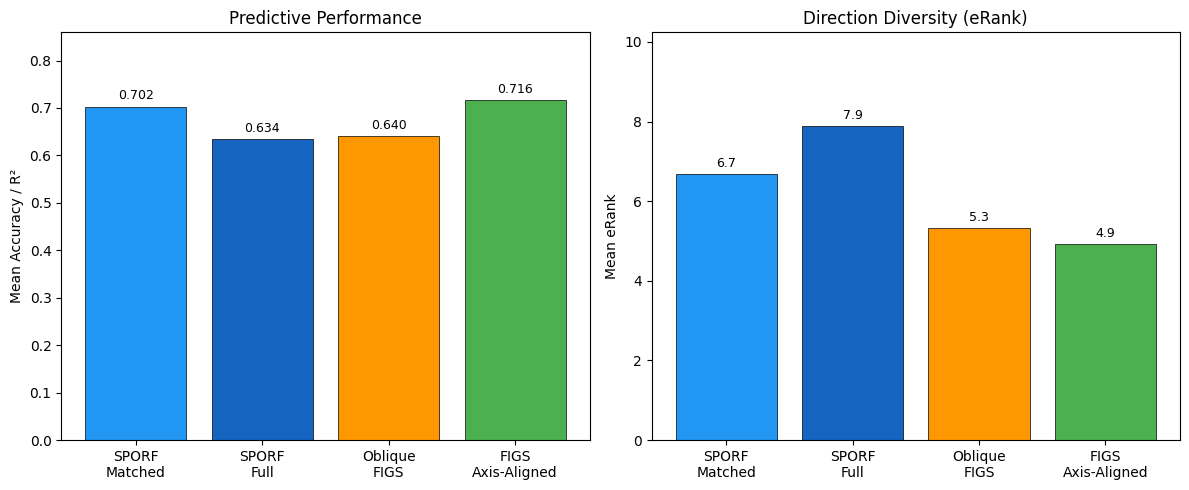


Saved results_comparison.png


In [12]:
# ── Summary Table ──
print("=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
header = f"{'Dataset':<20} {'Task':<6}"
for method in all_results:
    header += f" {method[:12]:>12} {'eRank':>6}"
print(header)
print("-" * len(header))

for ds_name in datasets_info:
    metric = "accuracy" if datasets_info[ds_name]["task_type"] == "classification" else "r2"
    row = f"{ds_name:<20} {datasets_info[ds_name]['task_type'][:6]:<6}"
    for method_name in all_results:
        if ds_name in all_results[method_name]:
            ds_r = all_results[method_name][ds_name]
            val = ds_r.get(f"mean_{metric}", 0)
            erank = ds_r.get("mean_erank", 0)
            row += f" {val:>12.4f} {erank:>6.2f}"
        else:
            row += f" {'N/A':>12} {'N/A':>6}"
    print(row)

# ── Bar Charts ──
methods = list(all_results.keys())
method_labels = ["SPORF\nMatched", "SPORF\nFull", "Oblique\nFIGS", "FIGS\nAxis-Aligned"]

# Collect mean metrics across datasets for each method
mean_accuracies = []
mean_eranks = []
for method_name in methods:
    accs = []
    eranks = []
    for ds_name, ds_result in all_results[method_name].items():
        metric_key = "accuracy" if datasets_info[ds_name]["task_type"] == "classification" else "r2"
        if f"mean_{metric_key}" in ds_result:
            accs.append(ds_result[f"mean_{metric_key}"])
        if "mean_erank" in ds_result:
            eranks.append(ds_result["mean_erank"])
    mean_accuracies.append(np.mean(accs) if accs else 0)
    mean_eranks.append(np.mean(eranks) if eranks else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy/R² comparison
colors = ['#2196F3', '#1565C0', '#FF9800', '#4CAF50']
bars1 = axes[0].bar(method_labels, mean_accuracies, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel("Mean Accuracy / R²")
axes[0].set_title("Predictive Performance")
axes[0].set_ylim(0, max(mean_accuracies) * 1.2 if max(mean_accuracies) > 0 else 1)
for bar, val in zip(bars1, mean_accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# eRank comparison
bars2 = axes[1].bar(method_labels, mean_eranks, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel("Mean eRank")
axes[1].set_title("Direction Diversity (eRank)")
axes[1].set_ylim(0, max(mean_eranks) * 1.3 if max(mean_eranks) > 0 else 1)
for bar, val in zip(bars2, mean_eranks):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved results_comparison.png")